## Auto loan prediction

In [1]:
# load relevant libraries
library(tidyverse)
library(caret)
# library(cowplot)
library(glmnet)

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

✔ ggplot2 3.3.5     ✔ purrr   0.3.4
✔ tibble  3.1.6     ✔ dplyr   1.0.7
✔ tidyr   1.2.0     ✔ stringr 1.4.0
✔ readr   2.1.2     ✔ forcats 0.5.1

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()

Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loaded glmnet 4.1-2



In [2]:
data_dictionary = read.csv("data/Data_Dictionary.csv")

data_dictionary

Variable,Description
<chr>,<chr>
ID,Client Loan application ID
Client_Income,Client Income in $
Car_Owned,Any Car owned by client before applying for the loan for another car (0 means No and 1 means otherwise)
Bike_Owned,Any bike owned by client (0 means No and 1 means otherwise)
Active_Loan,Any other active loan at the time of aplication of loan (0 means No and 1 means otherwise)
House_Own,Any house owned by client (0 means No and 1 means otherwise)
Child_Count,Number of children the client has
Credit_Amount,Credit amount of the loan in $
Loan_Annuity,Loan annuity in $


In [3]:
data = read.csv("data/train_dataset.csv")

# str(data)

# Convert the following to numeric
to_num = c('Client_Income', 'Credit_Amount', 'Loan_Annuity', 'Population_Region_Relative', 'Age_Days', 'Employed_Days', 
           'Registration_Days', 'ID_Days', 'Mobile_Tag', 'Score_Source_3') 

data[, to_num] = lapply(data[, to_num],as.numeric)

# Client_Occupation set blank to None, leave NA


to_factor = c('Application_Process_Hour', 'Application_Process_Day', 'Accompany_Client', 'Client_Income_Type',
             'Client_Education', 'Client_Marital_Status', 'Client_Gender', 'Loan_Contract_Type', 
              'Client_Housing_Type','Client_Occupation', 'Client_Permanent_Match_Tag', 'Client_Contact_Work_Tag', 
              'Type_Organization')

data[, to_factor] = lapply(data[, to_factor],as.factor)

str(data)

#Own house age to 0, Own_House will indicate if missing.

Warning message in lapply(data[, to_num], as.numeric):
“NAs introduced by coercion”
Warning message in lapply(data[, to_num], as.numeric):
“NAs introduced by coercion”
Warning message in lapply(data[, to_num], as.numeric):
“NAs introduced by coercion”
Warning message in lapply(data[, to_num], as.numeric):
“NAs introduced by coercion”
Warning message in lapply(data[, to_num], as.numeric):
“NAs introduced by coercion”
Warning message in lapply(data[, to_num], as.numeric):
“NAs introduced by coercion”
Warning message in lapply(data[, to_num], as.numeric):
“NAs introduced by coercion”
Warning message in lapply(data[, to_num], as.numeric):
“NAs introduced by coercion”
Warning message in lapply(data[, to_num], as.numeric):
“NAs introduced by coercion”


'data.frame':	121856 obs. of  40 variables:
 $ ID                        : int  12142509 12138936 12181264 12188929 12133385 12191614 12128086 12215264 12159147 12130547 ...
 $ Client_Income             : num  6750 20250 18000 15750 33750 ...
 $ Car_Owned                 : int  0 1 0 0 1 0 1 0 1 0 ...
 $ Bike_Owned                : int  0 0 0 0 0 1 1 0 1 0 ...
 $ Active_Loan               : int  1 1 1 1 1 1 0 1 0 0 ...
 $ House_Own                 : int  0 NA 0 1 0 1 1 1 1 1 ...
 $ Child_Count               : int  0 0 1 0 2 1 0 0 1 0 ...
 $ Credit_Amount             : num  61191 15282 59527 53870 133988 ...
 $ Loan_Annuity              : num  3417 1827 2788 2295 3547 ...
 $ Accompany_Client          : Factor w/ 8 levels "","##","Alone",..: 3 3 3 3 3 3 3 3 8 3 ...
 $ Client_Income_Type        : Factor w/ 9 levels "","Businessman",..: 3 7 7 6 3 7 6 6 3 6 ...
 $ Client_Education          : Factor w/ 6 levels "","Graduation",..: 6 2 3 6 6 6 6 6 2 6 ...
 $ Client_Marital_Status     : Factor

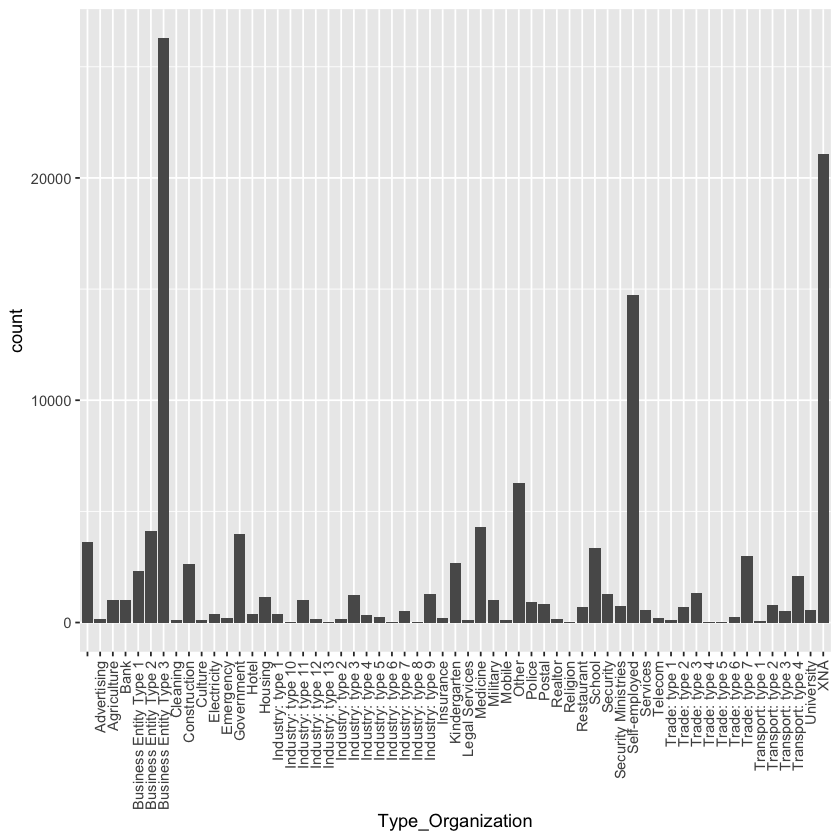

In [4]:
# Distribution of the 59 levels of the Type_Organization factor
ggplot(data) +
geom_bar(aes(x=Type_Organization)) +
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))


In [5]:
# Perform LASSO to identify categories to merge for Type Organization 

x_train <- model.matrix( ~ Type_Organization, data = data)
lasso_type_org = glmnet(x_train, data$Default, family = "binomial", alpha=1)


print(coef(lasso_type_org)[,20])


                            (Intercept)                             (Intercept) 
                           -2.432699004                             0.000000000 
           Type_OrganizationAdvertising            Type_OrganizationAgriculture 
                            0.000000000                             0.168766088 
                  Type_OrganizationBank Type_OrganizationBusiness Entity Type 1 
                           -0.109825148                             0.000000000 
Type_OrganizationBusiness Entity Type 2 Type_OrganizationBusiness Entity Type 3 
                            0.000000000                             0.094632709 
              Type_OrganizationCleaning           Type_OrganizationConstruction 
                            0.000000000                             0.336400696 
               Type_OrganizationCulture            Type_OrganizationElectricity 
                            0.000000000                             0.000000000 
             Type_Organizati

In [6]:
# Type_Organization variables with non-zero coefficient

vars_to_keep = c('XNA'
,'Self-employed'
,'Police'
,'Security'
,'Security Ministries'
,'School'
,'Construction'
,'Agriculture'
,'Transport: type 3'
,'Construction'
,'Insurance'
,'Bank')

data = data %>%
    mutate(Type_Organization = case_when(as.character(Type_Organization) %in% vars_to_keep ~ as.character(Type_Organization), TRUE ~ "Other") %>% as.factor())

str(data)


'data.frame':	121856 obs. of  40 variables:
 $ ID                        : int  12142509 12138936 12181264 12188929 12133385 12191614 12128086 12215264 12159147 12130547 ...
 $ Client_Income             : num  6750 20250 18000 15750 33750 ...
 $ Car_Owned                 : int  0 1 0 0 1 0 1 0 1 0 ...
 $ Bike_Owned                : int  0 0 0 0 0 1 1 0 1 0 ...
 $ Active_Loan               : int  1 1 1 1 1 1 0 1 0 0 ...
 $ House_Own                 : int  0 NA 0 1 0 1 1 1 1 1 ...
 $ Child_Count               : int  0 0 1 0 2 1 0 0 1 0 ...
 $ Credit_Amount             : num  61191 15282 59527 53870 133988 ...
 $ Loan_Annuity              : num  3417 1827 2788 2295 3547 ...
 $ Accompany_Client          : Factor w/ 8 levels "","##","Alone",..: 3 3 3 3 3 3 3 3 8 3 ...
 $ Client_Income_Type        : Factor w/ 9 levels "","Businessman",..: 3 7 7 6 3 7 6 6 3 6 ...
 $ Client_Education          : Factor w/ 6 levels "","Graduation",..: 6 2 3 6 6 6 6 6 2 6 ...
 $ Client_Marital_Status     : Factor

In [7]:
x_train <- model.matrix( ~ Client_Occupation, data = data)
lasso_client_occ = glmnet(x_train, data$Default, family = "binomial", alpha=1)

# lasso_client_occ
print(coef(lasso_client_occ)[,19])

                        (Intercept)                         (Intercept) 
                        -2.57208847                          0.00000000 
       Client_OccupationAccountants           Client_OccupationCleaning 
                        -0.08912193                          0.08907852 
           Client_OccupationCooking               Client_OccupationCore 
                         0.34122940                         -0.04370402 
           Client_OccupationDrivers    Client_OccupationHigh skill tech 
                         0.40043493                         -0.06674247 
                Client_OccupationHR                 Client_OccupationIT 
                         0.00000000                          0.00000000 
          Client_OccupationLaborers Client_OccupationLow-skill Laborers 
                         0.37632609                          0.80794401 
          Client_OccupationManagers           Client_OccupationMedicine 
                        -0.04363311                

In [8]:
# Client_Occupation variables with non-zero coefficient

vars_to_keep = c('Drivers', 'Low-skill Laborers', 'Security', 'Sales', 'Laborers', 'Cooking') 

data = data %>%
    mutate(Client_Occupation = case_when(as.character(Client_Occupation) %in% vars_to_keep ~ as.character(Client_Occupation), TRUE ~ "Other") %>% as.factor())

str(data)

'data.frame':	121856 obs. of  40 variables:
 $ ID                        : int  12142509 12138936 12181264 12188929 12133385 12191614 12128086 12215264 12159147 12130547 ...
 $ Client_Income             : num  6750 20250 18000 15750 33750 ...
 $ Car_Owned                 : int  0 1 0 0 1 0 1 0 1 0 ...
 $ Bike_Owned                : int  0 0 0 0 0 1 1 0 1 0 ...
 $ Active_Loan               : int  1 1 1 1 1 1 0 1 0 0 ...
 $ House_Own                 : int  0 NA 0 1 0 1 1 1 1 1 ...
 $ Child_Count               : int  0 0 1 0 2 1 0 0 1 0 ...
 $ Credit_Amount             : num  61191 15282 59527 53870 133988 ...
 $ Loan_Annuity              : num  3417 1827 2788 2295 3547 ...
 $ Accompany_Client          : Factor w/ 8 levels "","##","Alone",..: 3 3 3 3 3 3 3 3 8 3 ...
 $ Client_Income_Type        : Factor w/ 9 levels "","Businessman",..: 3 7 7 6 3 7 6 6 3 6 ...
 $ Client_Education          : Factor w/ 6 levels "","Graduation",..: 6 2 3 6 6 6 6 6 2 6 ...
 $ Client_Marital_Status     : Factor

In [9]:
str(data)

'data.frame':	121856 obs. of  40 variables:
 $ ID                        : int  12142509 12138936 12181264 12188929 12133385 12191614 12128086 12215264 12159147 12130547 ...
 $ Client_Income             : num  6750 20250 18000 15750 33750 ...
 $ Car_Owned                 : int  0 1 0 0 1 0 1 0 1 0 ...
 $ Bike_Owned                : int  0 0 0 0 0 1 1 0 1 0 ...
 $ Active_Loan               : int  1 1 1 1 1 1 0 1 0 0 ...
 $ House_Own                 : int  0 NA 0 1 0 1 1 1 1 1 ...
 $ Child_Count               : int  0 0 1 0 2 1 0 0 1 0 ...
 $ Credit_Amount             : num  61191 15282 59527 53870 133988 ...
 $ Loan_Annuity              : num  3417 1827 2788 2295 3547 ...
 $ Accompany_Client          : Factor w/ 8 levels "","##","Alone",..: 3 3 3 3 3 3 3 3 8 3 ...
 $ Client_Income_Type        : Factor w/ 9 levels "","Businessman",..: 3 7 7 6 3 7 6 6 3 6 ...
 $ Client_Education          : Factor w/ 6 levels "","Graduation",..: 6 2 3 6 6 6 6 6 2 6 ...
 $ Client_Marital_Status     : Factor

In [ ]:
mtrys<-seq(1,4,1)
ntrees<-c(10, 20)
combo_mtrTrees<-data.frame(expand.grid(mtrys, ntrees))
colnames(combo_mtrTrees)<-c('mtrys','ntrees')

tuneGrid <- expand.grid(.mtry = c(1: 4))
for (i in 1:length(ntrees)){
  ntree<-ntrees[i]
  set.seed(1990)
  rf_maxtrees <- train(Default~.,
                       data = data,
                       method = "rf",
                       importance=TRUE,
                       metric = "Accuracy",
                       tuneGrid = tuneGrid,
                       trControl = trainControl( method = "oob",
                                                 search = "grid",
                                                 classProbs = TRUE,
                                                 savePredictions = "final") ) 
    }

In [ ]:
print(ntree)